In [1]:
###-----------------
### Import libraries
###-----------------
from pathlib import Path  # Import Path for file system path operations and management
import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib

from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score  # Import function to calculate various metric

from collections.abc import Callable  # Type hinting callable objects/functions
from typing import Literal  # Literal type hints to restrict variable values

from sklearn.preprocessing import StandardScaler  # Import for standardizing features (zero mean, unit variance)
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torchsummary import summary
from torch.utils.data import DataLoader, Dataset # for loading data in batches
from utils.helper import fn_plot_torch_hist, fn_plot_confusion_matrix # Custom utility
from tqdm import tqdm

In [2]:
###----------------------
### Some basic parameters
###----------------------

# inpDir = Path('..') / '..' / 'input'
# outDir = Path('..') / 'output'
# modelDir = Path('..') / 'models'
# subDir = 'fifa_2019'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(seed = RANDOM_STATE) # Set Random Seed for reproducible  results
torch.manual_seed(RANDOM_STATE)

EPOCHS = 101 # number of epochs
BATCH_SIZE = 32
ALPHA = 0.001 # learning rate
TEST_SIZE = 0.2
TRAIN_SIZE = 452 * BATCH_SIZE

# parameters for Matplotlib
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'x-large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'x-large',
          'ytick.labelsize':'x-large'
         }

plt.rcParams.update(params)

CMAP = plt.cm.coolwarm
plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

In [3]:
###-----------------
### Hyper Parameters
###-----------------
EPOCHS = 30 # number of epochs
ALPHA = 0.001 # learning rate
BATCH_SIZE = 16 # mini batch size (number of rows)
TRAIN_SIZE = int(18 * BATCH_SIZE)
TEST_SIZE = 0.2
WEIGHT_DECAY = 0.001
PATIENCE = 20
LR_FACTOR = 0.1
LR_PATIENCE = 5
MIN_LR = 1e-6

IMG_HEIGHT = 32
IMG_WIDTH = 32
EPSILON = 1e-8

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tensorflow = 32 X 32 X 3
<p>
pytorch = 3 X 32 X 32

In pytorch  image's shape consists of channel first(mentioned above) thats why we cannot direclty show using matplot lib
<p> HENCE MADE A HELPER FUNCTION

In [5]:
def fn_imshow(image, ax=None, title=None, normalise= True):
    if ax is None:
        fig, ax = plt.subplots()
    # image coming as tensor hence convert to numpy
    image = image.numpy().transpose((1,2,0))

    if normalise:
        # from documentation
        mean = np.array([0.485, 0.456, 0.406]) #0.5
        std = np.array([0.229, 0.224, 0.225]) #0.225
        image = std * image + mean

        image = np.clip(image, 0, 1)
    
    # now image is ready for show
    ax.imshow(image)
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='both', length=0)
        
    return ax


In [6]:
# they process images with nrmlised form
transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        mean = [0.485, 0.456, 0.406], 
        std = [0.229, 0.224, 0.225] )
])


### from Library dataset

In [7]:
trainset = datasets.CIFAR10(root='../input/CIFAR10', 
                            train=True, 
                            download=True, 
                            transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, 
                                          batch_size=BATCH_SIZE, 
                                          shuffle=True,
                                          num_workers=4)
testset = datasets.CIFAR10(root='../input/CIFAR10', 
                            train=False, 
                            download=True, 
                            transform=transform)

testloader = torch.utils.data.DataLoader(testset, 
                                          batch_size=BATCH_SIZE, 
                                          shuffle=False,
                                          num_workers=4)

In [8]:
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [9]:
images, labels = next(iter(trainloader))
images.shape, labels.shape

(torch.Size([16, 3, 32, 32]), torch.Size([16]))

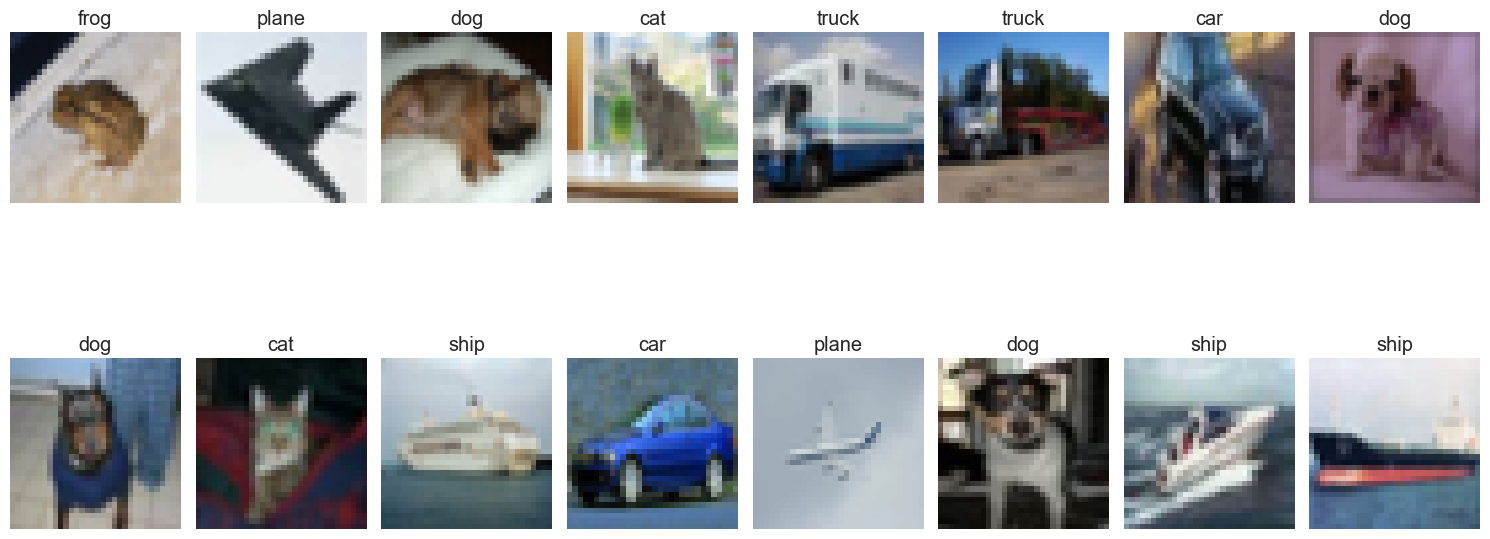

In [10]:
fig = plt.figure(figsize=(15,8))

for i in range(BATCH_SIZE):
    ax  = fig.add_subplot(BATCH_SIZE//8, 8, (i+1), xticks = [], yticks=[])
    fn_imshow(images[i], ax=ax, title=class_names[labels[i]], normalise=True)
plt.tight_layout()

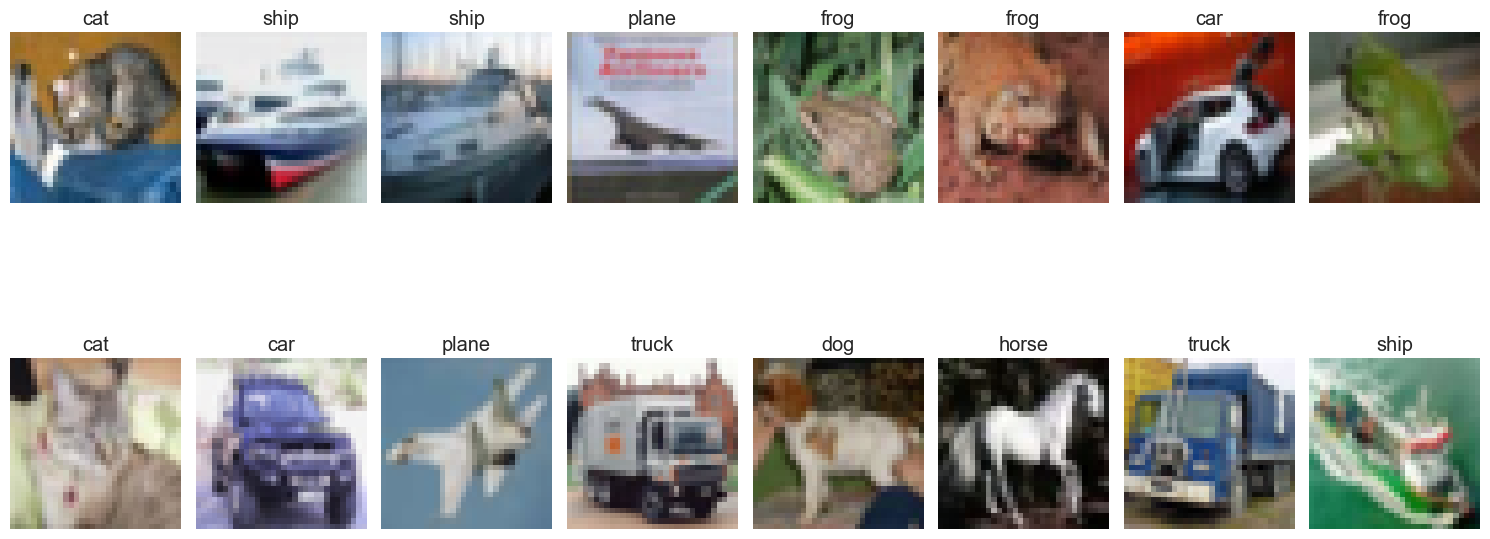

In [11]:
images, labels = next(iter(testloader))
fig = plt.figure(figsize=(15,8))

for i in range(BATCH_SIZE):
    ax  = fig.add_subplot(BATCH_SIZE//8, 8, (i+1), xticks = [], yticks=[])
    fn_imshow(images[i], ax=ax, title=class_names[labels[i]], normalise=True)
plt.tight_layout()

In [12]:
numChanels = 3 #cam hard code it. but what is it?
numClasses = len(class_names)

trainSteps = len(trainloader) // BATCH_SIZE
testSteps = len(testloader) // BATCH_SIZE
trainSteps, testSteps

(195, 39)

In [35]:
class Model(nn.Module):
    def __init__(self, input_dim, out_dim):
        super().__init__()

        dor1 = 0.1
        dor2 = 0.2
        dor3 = 0.3
        dor4 = 0.4
        dor5 = 0.5

        # Set 1
        out_channels1 = 32
        self.conv1 = nn.Conv2d(in_channels=input_dim, 
                               out_channels=out_channels1,
                               padding='same',
                               kernel_size=(3,3)) # 32 X 32 X 32
        self.bn1 = nn.BatchNorm2d(out_channels1)
        self.actv1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=(2,2)) #16 X 16 X 32
        self.do1 = nn.Dropout(dor1)

        # Set 2
        out_channels2 = 64
        self.conv2 = nn.Conv2d(in_channels=out_channels1,
                               out_channels=out_channels2,
                               padding='same',
                               kernel_size=(3,3))
        self.bn2 = nn.BatchNorm2d(out_channels2)
        self.actv2 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=(2,2))#8 X 8 X 64
        self.do2 = nn.Dropout(dor2)

        # Set 3
        out_channels3 = 128
        self.conv3 = nn.Conv2d(in_channels=out_channels2,
                               out_channels=out_channels3,
                               kernel_size=(3,3)) # 6 X 6 X 128
        self.bn3 = nn.BatchNorm2d(out_channels3)
        self.actv3 = nn.ReLU()
        self.maxpool3 = nn.MaxPool2d(kernel_size=(2,2)) # 3 X 3 X 128
        self.do3 = nn.Dropout(dor3)
        
        # Set 4
        out_channels4 = 256
        self.conv4 = nn.Conv2d(in_channels=out_channels3,
                               out_channels=out_channels4,
                               kernel_size=(3,3)) # 1 X 1 X 256
        self.bn4 = nn.BatchNorm2d(out_channels4)
        self.actv4 = nn.ReLU()
        self.do4 = nn.Dropout(dor4)
        # no maxpool in last

        # Set 5
        out_dim5 = 128
        self.fc1 = nn.Linear(in_features=1*1*out_channels4, out_features=out_dim5)
        self.bn5 = nn.BatchNorm1d(out_dim5) #1d
        self.actv5 = nn.ReLU()
        self.do5 = nn.Dropout(dor5) #output 128

        # Output layer
        self.fc2 = nn.Linear(out_dim5, out_dim) #output 10
        self.actv6 = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = self.do1(self.maxpool1(self.actv1(self.bn1(self.conv1(x)))))
        x = self.do2(self.maxpool2(self.actv2(self.bn2(self.conv2(x)))))
        x = self.do3(self.maxpool3(self.actv3(self.bn3(self.conv3(x)))))
        x = self.do4(self.actv4(self.bn4(self.conv4(x))))
        x = torch.flatten(x,1)
        x = self.do5(self.actv5(self.bn5(self.fc1(x))))
        x = self.actv6(self.fc2(x))
        return x


In [36]:
model = Model(input_dim=numChanels, out_dim=numClasses).to(device=device)
print(model)

Model(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (actv1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (do1): Dropout(p=0.1, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (actv2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (do2): Dropout(p=0.2, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (actv3): ReLU()
  (maxpool3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (do3): Dropout(p=0.3, inplace=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3)

In [37]:
_ = summary(model, (3, IMG_HEIGHT, IMG_WIDTH))
# summary?

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
         MaxPool2d-4           [-1, 32, 16, 16]               0
           Dropout-5           [-1, 32, 16, 16]               0
            Conv2d-6           [-1, 64, 16, 16]          18,496
       BatchNorm2d-7           [-1, 64, 16, 16]             128
              ReLU-8           [-1, 64, 16, 16]               0
         MaxPool2d-9             [-1, 64, 8, 8]               0
          Dropout-10             [-1, 64, 8, 8]               0
           Conv2d-11            [-1, 128, 6, 6]          73,856
      BatchNorm2d-12            [-1, 128, 6, 6]             256
             ReLU-13            [-1, 128, 6, 6]               0
        MaxPool2d-14            [-1, 12

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=ALPHA, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer,
                                                       min_lr=MIN_LR,
                                                       mode='min', factor=LR_FACTOR, 
                                                       patience=PATIENCE)

loss, test_loss = [], []
acc, test_acc = [], []
n_epoch = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    train_acc = 0.0

    for i, data in enumerate(trainloader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)

        batch_loss = loss_fn(outputs, labels)
        batch_acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())

        batch_loss.backward()
        optimizer.step()
        train_loss += batch_loss.item() * inputs.size(0)
        train_acc += batch_acc * inputs.size(0)

    train_loss = train_loss/len(trainloader)
    train_acc = train_acc/len(trainloader)
    loss.append(train_loss)
    acc.append(train_acc)


    # testing now
    with torch.inference_mode():
        model.eval()
        tst_loss = 0.0
        tst_acc = 0.0

        for i, data in enumerate(testloader):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            batch_loss = loss_fn(outputs, labels)
            batch_acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())

            tst_loss += batch_loss.item() * inputs.size(0)
            tst_acc += batch_acc * inputs.size(0)

        tst_loss = tst_loss/len(testloader)
        tst_acc = tst_acc/len(testloader)
        test_loss.append(tst_loss)
        test_acc.append(tst_acc)

    n_epoch.append(epoch)

    scheduler.step(tst_loss)

    if epoch%10 == 0: 
        print(f'Epoch {epoch}: loss = {train_loss:.4f}, accuracy = {train_acc:.3f}'+
                        f', val_loss = {tst_loss:.4f}, val_accuracy = {tst_acc:.3f}')
        
        

Epoch 0: loss = 23.8017, accuracy = 7.479, val_loss = 17.3790, val_accuracy = 9.838
